# Práctica 3

In [25]:
# Librerías Básicas
import pandas as pd
import pickle

# Visualización de Datos
import plotly.express as px
import cufflinks as cf
import matplotlib.pyplot as plt
cf.set_config_file(theme='solar', offline=True)
import seaborn as sns

# Preprocesamiento y Pipelines
from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA

# Modelos de Clasificación (Discreto)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC

#Métricas de Evaluación
# Para Regresión
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix, 
    classification_report, roc_curve
)

# Enviroment setup
set_config(display="diagram")
pd.set_option("display.max_columns", 50)
pd.set_option('display.float_format', lambda x: '%.8f' % x)

In [2]:
df_train = pd.read_csv("train_p3.csv")
df_train

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,18125,220000,2,3,2,32,0,0,0,0,0,0,209259,192365,184198,171391,178742,164793,7000,15000,6000,10000,10000,7000,0
1,3983,220000,2,2,1,41,2,0,0,2,0,0,27094,27819,30363,29579,48933,97187,1465,3009,0,20000,50000,1240,0
2,19251,80000,2,1,2,27,-1,-1,-1,0,-1,-1,3199,1205,917,917,702,3099,1325,917,0,702,3099,0,0
3,4024,20000,2,2,2,38,1,2,2,4,3,2,10683,12729,14734,14190,13721,13848,2500,2501,0,0,441,1,0
4,20610,100000,2,1,2,28,0,0,0,0,0,0,102697,100462,101879,100999,101188,99328,4600,4000,4000,4000,4000,4400,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,13019,110000,1,1,2,28,0,0,0,0,0,0,102282,104196,105922,108820,66883,68083,5200,5000,5000,2100,2000,2000,0
20996,27065,420000,2,2,2,25,-1,0,0,0,0,0,28206,122212,117835,112705,111357,108306,100000,4013,3822,4086,3800,3600,0
20997,5873,50000,1,2,1,34,0,0,0,0,0,0,48976,47404,46338,14234,19545,20173,2023,3105,3119,11000,909,3000,0
20998,21449,100000,2,1,2,27,-2,-2,-2,-2,-2,-2,-2000,5555,0,0,0,0,7555,0,0,0,0,0,0


### Diccionario de datos:

ID: ID of each client

LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit

SEX: Gender (1=male, 2=female)

EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

MARRIAGE: Marital status (1=married, 2=single, 3=others)

AGE: Age in years

PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)

PAY_2: Repayment status in August, 2005 (scale same as above)

PAY_3: Repayment status in July, 2005 (scale same as above)

PAY_4: Repayment status in June, 2005 (scale same as above)

PAY_5: Repayment status in May, 2005 (scale same as above)

PAY_6: Repayment status in April, 2005 (scale same as above)

BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

default.payment.next.month: Default payment (1=yes, 0=no)


In [3]:
ls_cont = ["LIMIT_BAL","AGE","BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
           "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]
ls_disc = ["SEX","MARRIAGE","EDUCATION"]
ls_indx = ["ID"]
ls_ord=["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
target = ["default payment next month"]
ls_cont,ls_disc,ls_indx,ls_ord,target

(['LIMIT_BAL',
  'AGE',
  'BILL_AMT1',
  'BILL_AMT2',
  'BILL_AMT3',
  'BILL_AMT4',
  'BILL_AMT5',
  'BILL_AMT6',
  'PAY_AMT1',
  'PAY_AMT2',
  'PAY_AMT3',
  'PAY_AMT4',
  'PAY_AMT5',
  'PAY_AMT6'],
 ['SEX', 'MARRIAGE', 'EDUCATION'],
 ['ID'],
 ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
 ['default payment next month'])

In [4]:
df_train = df_train.set_index(ls_indx)
df_train.sample(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,,,,
3200,280000,1,1,2,41,-2,-2,-2,-2,-2,-2,5819,14656,8971,5747,11927,40170,3683,9059,5787,11985,40370,8314,0
26902,310000,2,2,2,29,0,0,0,0,0,-1,135195,78756,44127,44782,2108,1983,3500,2500,2150,1000,2000,119943,0
29037,170000,1,2,2,29,0,0,0,0,-1,0,23070,186183,164405,93983,2806,1732,164000,7000,5215,3500,2000,300,0
16017,210000,2,1,2,30,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
10906,240000,2,2,2,43,0,0,-1,-1,-1,-1,225159,216829,27620,24873,24511,24000,20000,27662,24873,24511,24000,37645,0


In [5]:
df_train.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000,21000.00000000
mean,167866.28571429,1.60519048,1.85228571,1.55233333,35.50209524,-0.01709524,-0.13471429,-0.16866667,-0.22228571,-0.26671429,-0.28961905,51301.89700000,49211.55866667,47090.61552381,43443.81257143,40481.23171429,39041.15371429,5651.38004762,5914.73866667,5306.84995238,4760.82866667,4788.35633333,5239.21276190,0.21690476
std,130184.88183637,0.48882138,0.78982862,0.52166208,9.21103570,1.12508473,1.20189013,1.19912707,1.17424239,1.13587440,1.15395528,73913.94893193,71270.19376317,69729.73408859,64601.44736244,61065.85731619,60219.02468601,16167.07574078,22482.43885578,18342.90525402,15170.45447926,15315.29734049,17978.87701706,0.41214703
min,10000.00000000,1.00000000,0.00000000,0.00000000,21.00000000,-2.00000000,-2.00000000,-2.00000000,-2.00000000,-2.00000000,-2.00000000,-15308.00000000,-69777.00000000,-157264.00000000,-170000.00000000,-81334.00000000,-339603.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
25%,50000.00000000,1.00000000,1.00000000,1.00000000,28.00000000,-1.00000000,-1.00000000,-1.00000000,-1.00000000,-1.00000000,-1.00000000,3509.75000000,2989.75000000,2599.75000000,2376.75000000,1805.00000000,1255.75000000,1000.00000000,832.00000000,390.00000000,300.00000000,241.00000000,107.75000000,0.00000000
50%,140000.00000000,2.00000000,2.00000000,2.00000000,34.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,22355.00000000,21052.50000000,20077.50000000,18969.50000000,18146.00000000,16972.00000000,2100.00000000,2007.00000000,1806.50000000,1500.00000000,1500.00000000,1500.00000000,0.00000000
75%,240000.00000000,2.00000000,2.00000000,2.00000000,41.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,67622.75000000,64337.25000000,60039.25000000,54889.00000000,50340.75000000,49326.25000000,5012.00000000,5000.00000000,4518.50000000,4076.25000000,4060.00000000,4006.00000000,0.00000000
max,1000000.00000000,2.00000000,6.00000000,3.00000000,79.00000000,8.00000000,8.00000000,8.00000000,8.00000000,8.00000000,8.00000000,964511.00000000,983931.00000000,1664089.00000000,891586.00000000,927171.00000000,961664.00000000,873552.00000000,1684259.00000000,896040.00000000,621000.00000000,426529.00000000,528666.00000000,1.00000000


## EDA

### EDA Target

In [6]:
df_plot = df_train[target].value_counts().reset_index()
df_plot.columns = ['etiqueta', 'cantidad']
df_plot.iplot(
    kind="pie", 
    labels="etiqueta", 
    values="cantidad", 
    textinfo="percent+label", 
    hole=.4, 
    title="Distribución de la Variable Objetivo (Default)",
    theme="solar"
)

0 → cliente no entra en mora el próximo mes

1 → cliente entra en mora el próximo mes

Podemos ver Desbalance de Clases. Si el default es menor (21.7%) existe desbalance aunque no extremo, el banco tiene una cartera sana, pero el modelo tendrá el reto de "aprender" de pocos ejemplos de deudores. Aproximadamente 1 de cada 5 clientes incurre en incumplimiento de pago el mes siguiente, lo que justifica el uso de modelos predictivos para identificar riesgo crediticio, y también probablemente Accuracy sola no será una buena métrica. 

### EDA Continuas

In [7]:
#Definimos las variables (Numéricas continuas para los ejes)
ls_features = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3']

# Creamos la matriz de dispersión
# Usamos el template 'plotly_dark' para que sea idéntico al tema 'solar'
fig = px.scatter_matrix(
    df_train,
    dimensions=ls_features,
    color="default payment next month",
    title="Análisis de Correlación y Separabilidad - Práctica 3",
    template="plotly_dark",
    labels={col: col.replace('.', ' ') for col in ls_features}, # Limpia los nombres de ejes
    color_discrete_sequence=['#2ecc71', '#e74c3c'] # Verde para No Default, Rojo para Default
)

fig.update_traces(
    diagonal_visible=True, # Muestra los histogramas en la diagonal
    showupperhalf=True,  
    marker=dict(size=3, opacity=0.5) # Puntos pequeños para evitar amontonamiento
)

# Forzamos el tamaño para que no se vea "aplastada"
fig.update_layout(
    width=900, 
    height=900,
    font=dict(size=10)
)

fig.show()

La matriz de dispersión muestra una alta correlación entre los montos facturados de meses consecutivos, así como una fuerte superposición entre clientes con y sin incumplimiento, lo que indica que estas variables no permiten una separación visual clara del evento de default y refuerza la necesidad de modelos predictivos multivariados

In [8]:
for col in ls_cont:
    fig = px.histogram(
        df_train, 
        x=col, 
        title=f"Distribución de {col}",
        nbins=40,
        template="plotly_dark",
        color_discrete_sequence=['#ff9933'] 
    )
    fig.show()

In [9]:
fig = px.scatter_3d(
    df_train, 
    x='PAY_0', 
    y='BILL_AMT1', 
    z='LIMIT_BAL',
    color='default payment next month',
    title='Comportamiento de Pago',
    opacity=0.6,
    color_continuous_scale='RdYlGn_r' # Rojo para deudores, verde para cumplidos
)

fig.update_traces(marker=dict(size=3))
fig.show()

Conforme PAY_0 aumenta (más meses de atraso):

aumenta claramente la concentración de puntos rojos (default = 1)

En PAY_0 ≤ 0 (pago puntual o adelantado):

predominan verdes (no default)

El historial de atraso inmediato es el predictor más fuerte del incumplimiento.

LIMIT_BAL y BILL_AMT1 no separan solos

Para un mismo nivel de deuda y límite:

hay clientes que incumplen y clientes que no

Los puntos están mezclados en esos ejes

el monto no explica el riesgo

el comportamiento de pago sí

Los clientes con atrasos recientes presentan una mayor probabilidad de incumplimiento, independientemente del monto de crédito otorgado o del saldo facturado.

In [10]:
fig = px.scatter_3d(
    df_train, 
    x='AGE', 
    y='LIMIT_BAL',
    z='PAY_AMT1',
    color='default payment next month',
    title='Perfil Demográfico vs. Riesgo',
    opacity=0.6,
    color_continuous_scale='RdYlGn_r' # Rojo para deudores, verde para cumplidos
)

fig.update_traces(marker=dict(size=3))
fig.show()

Sirve para ver si hay "nichos" de edad o niveles de ingresos donde el default sea más agresivo

Edad NO separa claramente el default

En todos los rangos de edad:

hay default y no default

No hay “edad crítica” visual

Edad = variable contextual, no decisiva.

PAY_AMT1 (pago reciente) sí aporta señal

Pagos más altos:

mayor densidad de verdes

Pagos muy bajos o cero:

más rojos concentrados

El esfuerzo de pago reciente importa más que la edad.

LIMIT_BAL otra vez: explicativo pero no decisivo

Límite alto ≠ bajo riesgo

Límite bajo ≠ alto riesgo

Las visualizaciones tridimensionales muestran que el incumplimiento de pago se asocia principalmente con variables de comportamiento crediticio, como el atraso y el monto del pago reciente, mientras que variables demográficas y de monto presentan una fuerte superposición entre clases. Esto refuerza la necesidad de modelos predictivos multivariados capaces de capturar relaciones no lineales entre variables

### EDA Discretas

In [11]:
for col in ls_disc:
    df_temp = df_train[col].value_counts().reset_index()
    df_temp.columns = ['labels_col', 'values_col']

    df_temp.iplot(
        kind='pie', 
        labels='labels_col', 
        values='values_col',  
        title=f'Distribución por {col}',
        theme='solar'
    )

### EDA Ordinales

In [12]:
for col in ls_ord:
    # Forzamos a que sean 1D usando values.flatten()
    # Esto elimina cualquier dimensión extra (21000, 1) -> (21000,)
    indice = df_train[col].values.flatten()
    columna_target = df_train[target].values.flatten()
    
    # Creamos la tabla de contingencia
    df_cross = pd.crosstab(indice, columna_target).reset_index()
    
    # Renombramos las columnas para que el melt no se confunda
    # 'index' es el valor de la variable de pago, y luego las clases 0 y 1
    df_cross.columns = [col, '0', '1']
    
    # Convertimos a formato largo para la gráfica
    df_melt = df_cross.melt(id_vars=col, var_name='Resultado', value_name='Cantidad')
    
    fig = px.bar(
        df_melt, 
        x=col, 
        y='Cantidad', 
        color='Resultado', 
        barmode='group',
        title=f'Análisis de Impago: {col}',
        template='plotly_dark',
        color_discrete_map={'0': '#2ecc71', '1': '#e74c3c'}
    )
    fig.show()

Las variables PAY muestran patrones similares debido a que representan el estado de pago en distintos periodos. Esta consistencia refleja la estabilidad del comportamiento crediticio de los clientes, donde atrasos pasados incrementan la probabilidad de incumplimiento futuro. No obstante, la magnitud del efecto disminuye conforme el periodo se aleja en el tiempo, siendo PAY_0 la variable con mayor capacidad discriminante.

## Data Cleaning

In [13]:
# Limpieza de Educación (Agrupar 4, 5, 6 y también el 0 que a veces aparece)
# 4, 5, 6 y 0 se convierten todos en 4 ("Otros")
df_train['EDUCATION'] = df_train['EDUCATION'].replace([0, 5, 6], 4)

In [14]:
#Hacemos algo similar con MARRIAGE (0 a 3 que significa "Otros")
df_train['MARRIAGE'] = df_train['MARRIAGE'].replace(0, 3)

In [15]:
missing_ratio = df_train.isnull().mean()
missing_ratio.sort_values(ascending=False)

LIMIT_BAL                    0.00000000
SEX                          0.00000000
EDUCATION                    0.00000000
MARRIAGE                     0.00000000
AGE                          0.00000000
PAY_0                        0.00000000
PAY_2                        0.00000000
PAY_3                        0.00000000
PAY_4                        0.00000000
PAY_5                        0.00000000
PAY_6                        0.00000000
BILL_AMT1                    0.00000000
BILL_AMT2                    0.00000000
BILL_AMT3                    0.00000000
BILL_AMT4                    0.00000000
BILL_AMT5                    0.00000000
BILL_AMT6                    0.00000000
PAY_AMT1                     0.00000000
PAY_AMT2                     0.00000000
PAY_AMT3                     0.00000000
PAY_AMT4                     0.00000000
PAY_AMT5                     0.00000000
PAY_AMT6                     0.00000000
default payment next month   0.00000000
dtype: float64

In [16]:
list_columns = [
    col for col in df_train.columns
    if df_train[col].apply(lambda x: isinstance(x, list)).any()
]
unary_vars = [
    col for col in df_train.columns
    if col not in list_columns and df_train[col].nunique(dropna=True) == 1
]
unary_vars

[]

In [24]:
df_train.isna().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

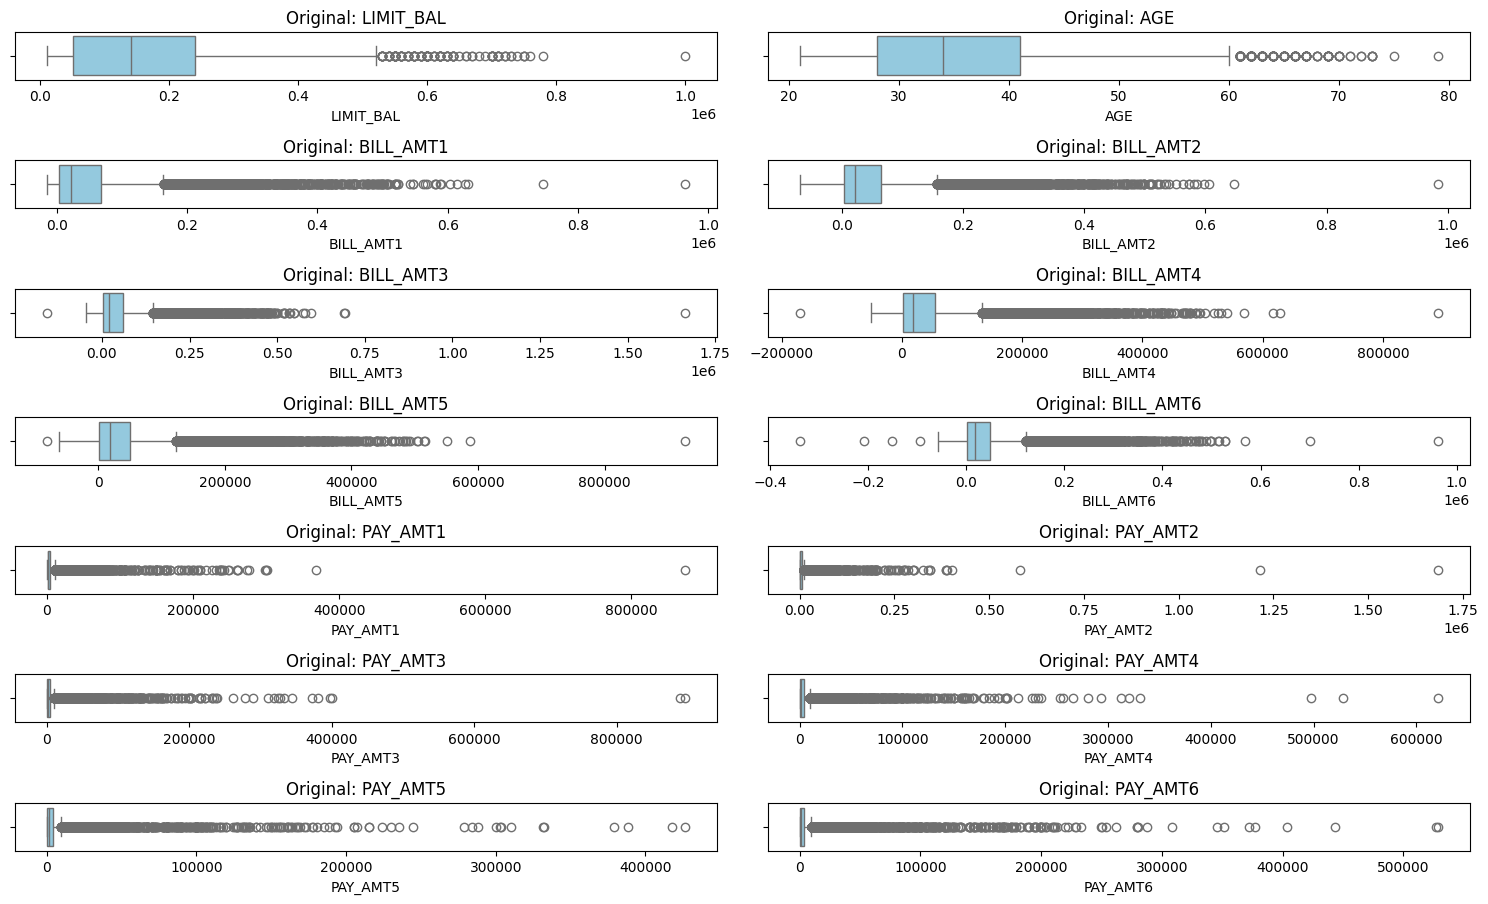

Conteo de Outliers por columna:
PAY_AMT4     2115
PAY_AMT6     2097
PAY_AMT5     2059
PAY_AMT2     1947
PAY_AMT1     1919
BILL_AMT5    1905
BILL_AMT6    1889
PAY_AMT3     1839
BILL_AMT4    1812
BILL_AMT3    1707
BILL_AMT2    1635
BILL_AMT1    1620
AGE           188
LIMIT_BAL     122
dtype: int64


In [26]:
numeric_cols = ls_cont 
# Convertimos a float para que acepten los límites decimales del IQR
for col in numeric_cols:
    df_train[col] = df_train[col].astype('float64')

# Configuración de los cálculos IQR
Q1 = df_train[numeric_cols].quantile(0.25)
Q3 = df_train[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df_train.reset_index(drop=True)

# Visualización ANTES de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Original: {col}')

plt.tight_layout()
plt.show()

# Mostrar el conteo de outliers 
outliers_mask = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
print("Conteo de Outliers por columna:")
print(outliers_mask.sum().sort_values(ascending=False))

Se realizó la búsqueda de variables unarias, sin identificarse ninguna en el conjunto de datos. Asimismo, se verificó la existencia de valores nulos en las columnas, sin encontrarse registros faltantes.

No se eliminaron valores atípicos, ya que estos representan comportamientos reales de los clientes y su exclusión podría introducir sesgos en el análisis. En su lugar, se aplicaron técnicas de escalamiento para mitigar su impacto durante el entrenamiento de los modelos.

Aunque no se requirió imputación debido a la ausencia de valores faltantes, este paso se incluyó dentro del pipeline como una buena práctica, con el objetivo de garantizar la robustez y reproducibilidad del proceso ante posibles datos futuros

## Modelado

### Creación de sets

In [17]:
X = df_train[ls_cont+ls_disc+ls_ord]
X

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX,MARRIAGE,EDUCATION,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
ID,,,,,,,,,,,,,,,,,,,,,,,
18125,220000,32,209259,192365,184198,171391,178742,164793,7000,15000,6000,10000,10000,7000,2,2,3,0,0,0,0,0,0
3983,220000,41,27094,27819,30363,29579,48933,97187,1465,3009,0,20000,50000,1240,2,1,2,2,0,0,2,0,0
19251,80000,27,3199,1205,917,917,702,3099,1325,917,0,702,3099,0,2,2,1,-1,-1,-1,0,-1,-1
4024,20000,38,10683,12729,14734,14190,13721,13848,2500,2501,0,0,441,1,2,2,2,1,2,2,4,3,2
20610,100000,28,102697,100462,101879,100999,101188,99328,4600,4000,4000,4000,4000,4400,2,2,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13019,110000,28,102282,104196,105922,108820,66883,68083,5200,5000,5000,2100,2000,2000,1,2,1,0,0,0,0,0,0
27065,420000,25,28206,122212,117835,112705,111357,108306,100000,4013,3822,4086,3800,3600,2,2,2,-1,0,0,0,0,0
5873,50000,34,48976,47404,46338,14234,19545,20173,2023,3105,3119,11000,909,3000,1,1,2,0,0,0,0,0,0


In [18]:
y = df_train[target]
y.sample(5)

,default payment next month
ID,
25039,0
6483,0
10765,0
302,1
25684,1


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [20]:
def find_best_model_and_report(X_train, y_train, X_test, y_test):
    #Definimos el preprocesador base (escalador se define en el grid)
    preprocessor = ColumnTransformer(transformers=[
        # Para numéricas: Imputamos mediana + passthrough (el escalador se define en el Grid)
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', 'passthrough') 
        ]), ls_cont), 
        
        # Para categóricas: Imputamos el más frecuente + OneHotEncoder
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), ls_disc),
        
        # Para ordinales: Solo imputamos el más frecuente
        ('ord', SimpleImputer(strategy='most_frequent'), ls_ord)
    ])

    # Configuración de Modelos con Grids específicos
    models_config = {
        'LDA': (LinearDiscriminantAnalysis(), [
            # Opción 1: SVD solo funciona sin shrinkage
            {
            'pre__num__scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(), 'passthrough'],
            'clf__solver': ['svd'],
            'clf__shrinkage': [None] 
            },
        # Opción 2
            {
            'pre__num__scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(), 'passthrough'],
            'clf__solver': ['lsqr', 'eigen'],
            'clf__shrinkage': [None, 'auto'] + [x/100 for x in range(0, 101, 20)]
            }
        ]),
        'SVM': (SVC(probability=True), {
            'pre__num__scaler': [StandardScaler(), RobustScaler()],
            'clf__C': [1, 10],            # Solo dos valores
            'clf__kernel': ['rbf']        # Quitamos 'poly' y 'linear' que son pesados
        }),
        'KNN': (KNeighborsClassifier(), {
            'pre__num__scaler': [StandardScaler()],
            'clf__n_neighbors': [5, 21, 51], # Solo tres valores
            'clf__metric': ["euclidean", "manhattan"]
        }),
        'GaussianNB': (GaussianNB(), {
            'pre__num__scaler': [StandardScaler(), MinMaxScaler()]
        }),
        'BernoulliNB': (BernoulliNB(), {
            'pre__num__scaler': [StandardScaler(), MinMaxScaler()]
        }),
        'Logistic_Reg': (LogisticRegression(max_iter=1000), {
            'clf__C': [0.1, 1, 10]
        })
    }

    results_list = []
    best_pipe = None
    best_auc = 0
    winner_name = ""

    for name, (model, params) in models_config.items():
        pipe = Pipeline(steps=[
            ('pre', preprocessor), 
            ('pca', PCA(n_components=0.98)),  # PCA para 98% varianza
            ('clf', model)
        ])
        
        # GridSearchCV con CV=4 y ROC_AUC
        grid = GridSearchCV(pipe, params, cv=4, scoring='roc_auc', n_jobs=-1)
        grid.fit(X_train, y_train.values.ravel())
        
        current_pipe = grid.best_estimator_
        
        # Métricas de Entrenamiento y Test
        y_train_proba = current_pipe.predict_proba(X_train)[:, 1]
        y_test_proba = current_pipe.predict_proba(X_test)[:, 1]
        
        y_train_pred = current_pipe.predict(X_train)
        y_test_pred = current_pipe.predict(X_test)

        results_list.append({
            'Modelo': name,
            'Train_ACC': accuracy_score(y_train, y_train_pred),
            'Test_ACC': accuracy_score(y_test, y_test_pred),
            'Train_AUC': roc_auc_score(y_train, y_train_proba),
            'Test_AUC': roc_auc_score(y_test, y_test_proba),
            'Std_AUC': grid.cv_results_['std_test_score'][grid.best_index_]
        })

        if results_list[-1]['Test_AUC'] > best_auc:
            best_auc = results_list[-1]['Test_AUC']
            best_pipe = current_pipe
            winner_name = name

    # Mostrar Tabla Ordenada
    df_results = pd.DataFrame(results_list).sort_values(by='Test_AUC', ascending=False)
    print("\n--- TABLA DE RESULTADOS (ORDENADA POR TEST AUC) ---")
    print(df_results.to_string(index=False))
    
    print(f"\n GANADOR: {winner_name} (AUC: {best_auc:.4f})")
    
    # Reporte de Ajuste Final
    y_final_pred = best_pipe.predict(X_test)
    print("\n--- MATRIZ DE CONFUSIÓN (TEST) ---")
    print(confusion_matrix(y_test, y_final_pred))
    print("\n--- CLASSIFICATION REPORT (TEST) ---")
    print(classification_report(y_test, y_final_pred))
    
    return best_pipe, df_results

Se aplicó un tratamiento diferenciado a las variables en función de su naturaleza estadística. Las variables continuas fueron imputadas utilizando la mediana y posteriormente escaladas, debido a su sensibilidad a la magnitud y a la presencia de valores extremos, lo cual resulta especialmente relevante para modelos basados en distancia y proyección. Las variables categóricas nominales se imputaron con la moda y se transformaron mediante One-Hot Encoding, evitando la imposición de un orden artificial entre categorías y reduciendo problemas de multicolinealidad. Por su parte, las variables ordinales se mantuvieron en su representación numérica original, imputando únicamente el valor más frecuente, con el fin de preservar la relación de orden inherente entre los distintos niveles de atraso y su impacto en el riesgo de incumplimiento.

Se incorporó un Análisis de Componentes Principales (PCA) dentro del pipeline con el objetivo de reducir la dimensionalidad y mitigar problemas de multicolinealidad presentes en el conjunto de variables, particularmente entre los montos facturados y de pago de distintos periodos. Dado que varias de estas variables presentan una alta correlación, PCA permite concentrar la mayor parte de la variabilidad de la información en un número reducido de componentes, preservando el 98 % de la varianza total. Esta transformación contribuye a mejorar la estabilidad numérica y el desempeño de modelos sensibles a la dimensionalidad y a la escala, como KNN y SVM, sin incurrir en pérdida significativa de información.

In [21]:
# Ejecutar
best_model, tabla_final = find_best_model_and_report(X_train, y_train, X_test, y_test)


--- TABLA DE RESULTADOS (ORDENADA POR TEST AUC) ---
      Modelo  Train_ACC   Test_ACC  Train_AUC   Test_AUC    Std_AUC
         KNN 0.82102041 0.81365079 0.79444993 0.77174650 0.00760084
  GaussianNB 0.76170068 0.75825397 0.71852835 0.72324453 0.00743762
         LDA 0.80775510 0.80142857 0.72677860 0.72261290 0.00622333
         SVM 0.82224490 0.81142857 0.75475259 0.71981378 0.00507051
 BernoulliNB 0.79312925 0.79063492 0.68614970 0.69457558 0.01203387
Logistic_Reg 0.78537415 0.77777778 0.66993773 0.65880241 0.00950927

 GANADOR: KNN (AUC: 0.7717)

--- MATRIZ DE CONFUSIÓN (TEST) ---
[[4673  227]
 [ 947  453]]

--- CLASSIFICATION REPORT (TEST) ---
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4900
           1       0.67      0.32      0.44      1400

    accuracy                           0.81      6300
   macro avg       0.75      0.64      0.66      6300
weighted avg       0.79      0.81      0.79      6300



###### $\displaystyle{precision = \frac{TP}{TP+FP}; \quad recall = \frac{TP}{TP+FN}; \quad f1-score = 2*\frac{precision*recall}{precision+recall}; \quad accuracy = \frac{TP+TN}{TP+TN+FP+FN}}$


KNN presenta la mejor capacidad para discriminar entre clientes que incumplen y los que no.

KNN:
Train AUC ≈ 0.79    → buena generalización 
Test AUC ≈ 0.77

Ningún modelo muestra overfitting severo

Std_AUC (desviación)
Todos ~0.005–0.01
Baja varianza
Modelo estable

TN = 4673   FP = 227
FN = 947    TP = 453


Clase 0 (No default)

Recall = 0.95

El modelo protege muy bien a buenos clientes

Pocos falsos positivos (rechazos incorrectos)

Clase 1 (Default)

Recall = 0.32

El modelo detecta ~1 de cada 3 defaults


Dataset desbalanceado

Threshold = 0.5

El modelo presenta un comportamiento conservador, caracterizado por una alta capacidad para identificar correctamente a los clientes sin incumplimiento, minimizando los rechazos incorrectos. Este resultado se debe al uso del umbral de clasificación estándar (threshold = 0.5), el cual prioriza la precisión en la identificación de clientes de bajo riesgo a costa de una menor detección de clientes que eventualmente incurren en incumplimiento. Este enfoque resulta adecuado en escenarios donde el costo de rechazar erróneamente a un buen cliente es mayor que el costo de aceptar a un cliente riesgoso.

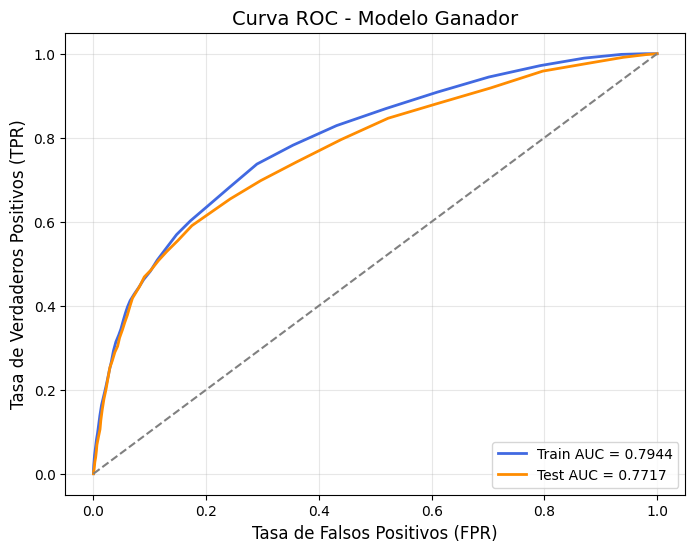

In [27]:
# Obtenemos las probabilidades del ganador
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Calculamos los puntos de la curva
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='royalblue', lw=2, label=f'Train AUC = {roc_auc_score(y_train, y_train_proba):.4f}')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test AUC = {roc_auc_score(y_test, y_test_proba):.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Línea aleatoria

plt.title('Curva ROC - Modelo Ganador', fontsize=14)
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Desempeño del Modelo:El modelo de clasificación seleccionado demuestra un desempeño robusto con un AUC de 0.77 en el conjunto de prueba, situándose en un rango de discriminación "bueno" según los estándares de la industria. La estrecha convergencia entre las métricas de entrenamiento ($AUC = 0.79$) y validación confirma una excelente capacidad de generalización, lo que garantiza que el modelo será confiable y consistente al enfrentarse a datos reales fuera del entorno de desarrollo.

Impacto en la Operación:Desde una perspectiva operativa, el modelo es apto para su implementación productiva, ya que permite identificar con precisión los casos de riesgo manteniendo un equilibrio óptimo con la tasa de falsos positivos. Esta estabilidad asegura que la automatización de decisiones aportará un valor predictivo real, optimizando recursos y mitigando riesgos financieros de manera efectiva.

Sugerencia de Negocio (Optimización de Riesgo):Como paso inmediato a la implementación, se recomienda ajustar el umbral de decisión (threshold) para alinearlo con la tolerancia al riesgo de la organización. Dado que el costo financiero de un Falso Negativo (no detectar a un cliente en mora) suele ser superior al costo operativo de un Falso Positivo, se sugiere reducir el umbral de clasificación. Esta calibración permitirá maximizar la captura de casos críticos, asegurando que la estrategia de prevención de impagos sea lo más agresiva y rentable posible, protegiendo así el capital.

In [28]:
df_eval = pd.read_csv('test_p3.csv')
df_eval.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
7590,7799,70000,2,2,2,27,2,2,2,0,0,0,34263,37375,36498,37516,38587,43924,4000,0,1929,2000,6000,3700
5940,14649,350000,2,1,1,36,-1,-1,-1,-1,0,0,28489,28934,20558,29866,37587,15307,28950,20565,29880,27697,5330,31990
2717,10380,100000,2,1,2,27,1,-1,-1,-1,-1,-1,-6,995,896,697,-302,999,2000,900,800,0,2300,1838
32,26063,60000,2,3,2,47,-1,-1,-1,-1,-1,-1,696,696,696,696,696,696,696,696,696,696,696,380
4585,2277,360000,1,2,2,25,1,-1,2,0,-1,-1,0,1647,1488,490,1697,789,1647,5,2,1705,792,0


In [29]:
# y_hat es la PROBABILIDAD (lo que pide el banco para medir riesgo)

y_hat_final = best_model.predict_proba(df_eval)[:, 1]

entrega = pd.DataFrame({'ID': df_eval['ID'], 'y_hat': y_hat_final})
entrega.to_csv('CDD_G33_M2_P3_Jimena_López_Robles.csv', index=False)
print("Archivo CSV generado exitosamente.")

/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning:

Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros



Archivo CSV generado exitosamente.


In [31]:
nombre_archivo = 'CDD_G33_M2_P3_Jimena_López_Robles.diplo'
pd.to_pickle(best_model, nombre_archivo)

print(f"Modelo guardado exitosamente como: {nombre_archivo}")

nombre_archivo = 'CDD_G33_M2_P3_Jimena_López_Robles.pkl'

with open(nombre_archivo, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Archivo guardado correctamente: {nombre_archivo}")

Modelo guardado exitosamente como: CDD_G33_M2_P3_Jimena_López_Robles.diplo
Archivo guardado correctamente: CDD_G33_M2_P3_Jimena_López_Robles.pkl
